# NHL Playoff Predictor Analysis

This notebook answers two questions:

1. **How well does a team's regular-season record predict whether they win a playoff series?**
2. **Which single regular-season stat is the strongest predictor of playoff series wins?**

### Methodology

For each of the 225 playoff series across 15 seasons (2010–11 through 2024–25), we pair the two teams' regular-season stats and record which team won the series. We then measure how often the "better" team by each stat actually won.

Each stat is evaluated on three metrics:
- **Accuracy** — the percentage of series where the team with the better stat won. 50% is a coin flip; anything above that is predictive signal.
- **Correlation (r)** — point-biserial correlation between the stat differential and the series outcome. Positive means the better-stat team wins more often; negative means the opposite. Values near 0 mean the stat has little to no relationship with the outcome.
- **AUC** — area under the ROC curve from a logistic regression using only that one stat. 0.5 is random; 1.0 is perfect. This captures not just *whether* the better-stat team wins, but *how much* the size of the gap matters.

In [1]:
import sys
sys.path.insert(0, '../scripts')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from predictor_analysis import load_matchups, analyze, STAT_LABELS, LOWER_IS_BETTER

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

df = load_matchups()
print(f"{len(df)} series across {df['season'].nunique()} seasons")
df.head()

225 series across 15 seasons


,season,round,series_letter,team_hi,team_lo,winner,hi_won,series_result,points_hi,points_lo,...,goal_diff_diff,points_pct_hi,points_pct_lo,points_pct_diff,goals_for_pg_hi,goals_for_pg_lo,goals_for_pg_diff,goals_against_pg_hi,goals_against_pg_lo,goals_against_pg_diff
0,20102011,1,A,WSH,NYR,WSH,1,4-1,107,93,...,-8,0.652439,0.567073,0.085366,2.731707,2.841463,-0.109756,2.402439,2.414634,-0.012195
1,20102011,1,B,PHI,BUF,PHI,1,4-3,106,96,...,20,0.646341,0.585366,0.060976,3.158537,2.987805,0.170732,2.719512,2.792683,-0.073171
2,20102011,1,C,BOS,MTL,BOS,1,4-3,103,96,...,44,0.628049,0.585366,0.042683,3.000000,2.634146,0.365854,2.378049,2.548780,-0.170732
3,20102011,1,D,PIT,TBL,TBL,0,4-3,106,103,...,32,0.646341,0.628049,0.018293,2.902439,3.012195,-0.109756,2.426829,2.926829,-0.500000
4,20102011,1,E,VAN,CHI,VAN,1,4-3,117,97,...,44,0.713415,0.591463,0.121951,3.195122,3.146341,0.048780,2.256098,2.743902,-0.487805


In [2]:
# How often does the higher-points team win each round?
round_summary = (
    df.groupby('round')['hi_won']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'hi_team_win_rate', 'count': 'n_series'})
    .reset_index()
)
round_summary['hi_team_win_rate'] = round_summary['hi_team_win_rate'].map('{:.1%}'.format)
print("Higher regular-season points team win rate by round:")
round_summary

Higher regular-season points team win rate by round:


,round,hi_team_win_rate,n_series
0,1,63.3%,120
1,2,45.0%,60
2,3,33.3%,30
3,4,60.0%,15


In [3]:
# Full predictor leaderboard
results = analyze(df)
results[['label', 'accuracy', 'correlation', 'auc', 'n_series']].style \
    .format({'accuracy': '{:.1%}', 'correlation': '{:.3f}', 'auc': '{:.3f}'}) \
    .background_gradient(subset=['accuracy', 'auc'], cmap='Blues') \
    .set_caption('Regular-season stat predictive power for playoff series wins')

,label,accuracy,correlation,auc,n_series
0,Goals Against / Game,59.6%,0.215,0.622,225
1,Goal Differential,58.9%,0.219,0.644,225
2,Wins,56.8%,0.210,0.636,225
3,Win %,56.8%,0.204,0.634,225
4,Points,54.8%,0.220,0.644,225
5,Points %,54.8%,0.223,0.637,225
6,Goals For / Game,51.6%,0.024,0.513,225


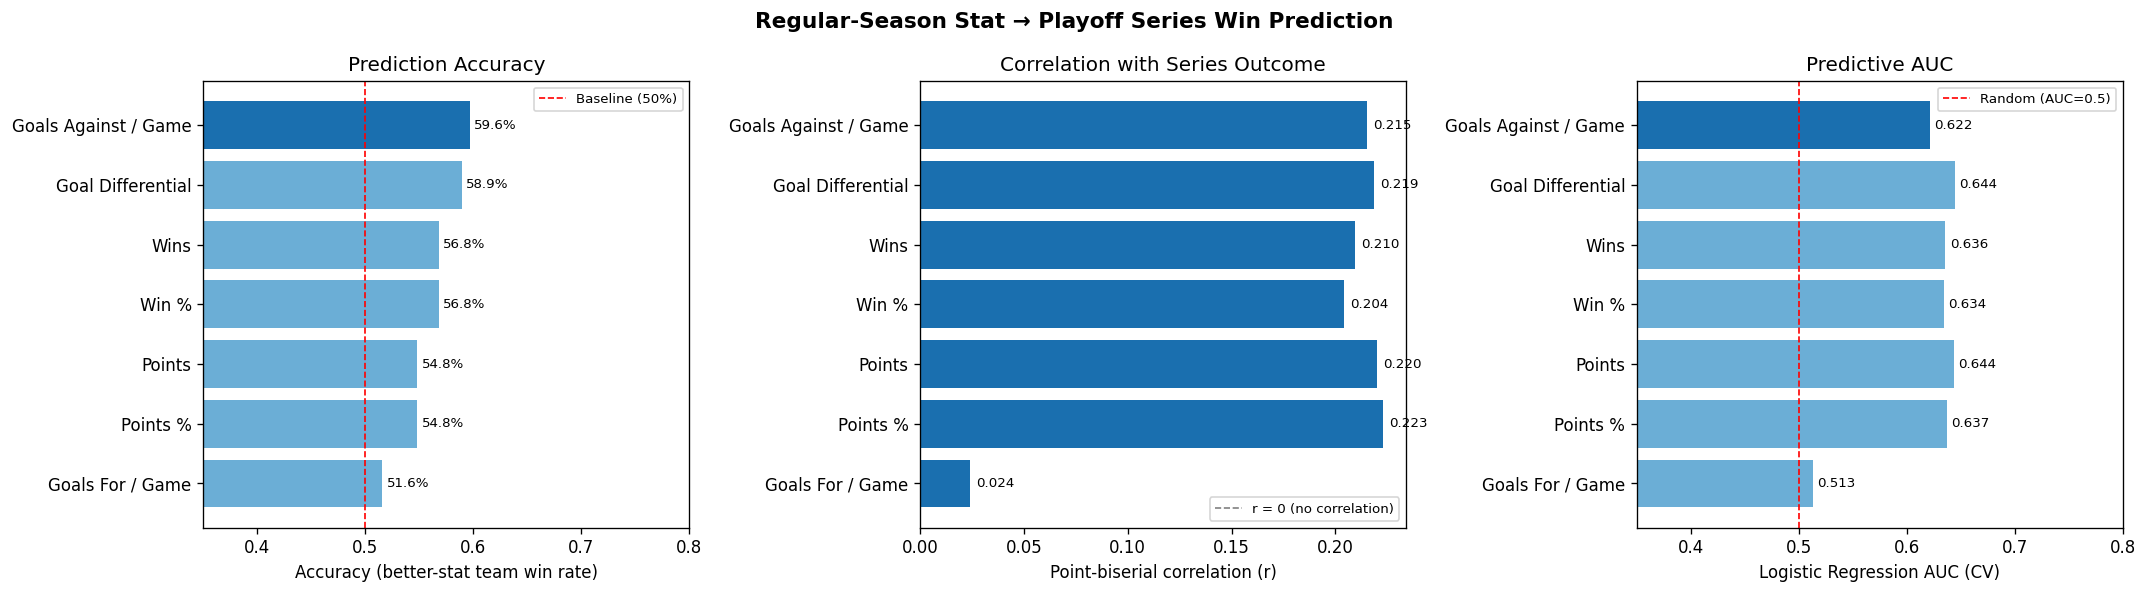

In [4]:
# Three-panel chart: accuracy, correlation (r), and AUC
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Regular-Season Stat → Playoff Series Win Prediction', fontsize=13, fontweight='bold')

colors = ['#1a6faf' if i == 0 else '#6baed6' for i in range(len(results))]

# Accuracy
ax = axes[0]
bars = ax.barh(results['label'][::-1], results['accuracy'][::-1], color=colors[::-1])
ax.axvline(0.5, color='red', linestyle='--', linewidth=1, label='Baseline (50%)')
ax.set_xlabel('Accuracy (better-stat team win rate)')
ax.set_title('Prediction Accuracy')
ax.set_xlim(0.35, 0.80)
ax.legend(fontsize=8)
for bar, val in zip(bars, results['accuracy'][::-1]):
    ax.text(bar.get_width() + 0.004, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=8)

# Correlation (r) — can be negative, centre on 0
ax = axes[1]
corr_vals = results['correlation'][::-1]
bar_colors = ['#1a6faf' if v >= 0 else '#d7301f' for v in corr_vals]
bars = ax.barh(results['label'][::-1], corr_vals, color=bar_colors)
ax.axvline(0, color='gray', linestyle='--', linewidth=1, label='r = 0 (no correlation)')
ax.set_xlabel('Point-biserial correlation (r)')
ax.set_title('Correlation with Series Outcome')
ax.legend(fontsize=8)
for bar, val in zip(bars, corr_vals):
    x = bar.get_width() + 0.003 if val >= 0 else bar.get_width() - 0.003
    ha = 'left' if val >= 0 else 'right'
    ax.text(x, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', ha=ha, fontsize=8)

# AUC
ax = axes[2]
bars = ax.barh(results['label'][::-1], results['auc'][::-1], color=colors[::-1])
ax.axvline(0.5, color='red', linestyle='--', linewidth=1, label='Random (AUC=0.5)')
ax.set_xlabel('Logistic Regression AUC (CV)')
ax.set_title('Predictive AUC')
ax.set_xlim(0.35, 0.80)
ax.legend(fontsize=8)
for bar, val in zip(bars, results['auc'][::-1]):
    ax.text(bar.get_width() + 0.004, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

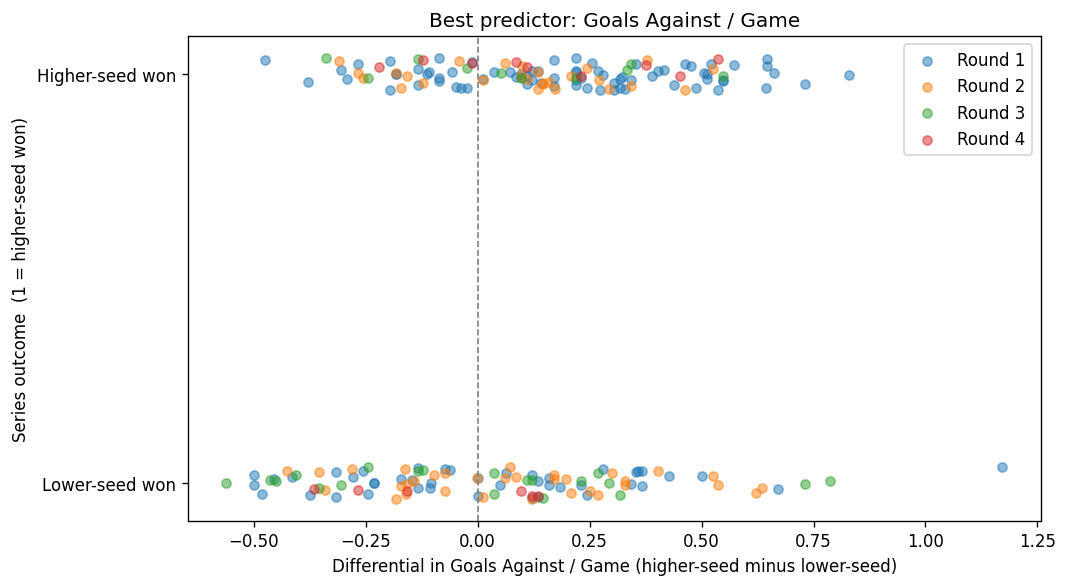

Best predictor: Goals Against / Game
Accuracy: 59.6%  |  AUC: 0.622  |  r = 0.215


In [5]:
# Scatter: best stat differential vs outcome, coloured by round
best_stat = results.iloc[0]['stat']
best_label = results.iloc[0]['label']
diff_col = f'{best_stat}_diff'

plot_df = df[[diff_col, 'hi_won', 'round', 'season']].dropna()
if best_stat in LOWER_IS_BETTER:
    plot_df[diff_col] = -plot_df[diff_col]

fig, ax = plt.subplots(figsize=(9, 5))
for rnd, grp in plot_df.groupby('round'):
    jitter = np.random.uniform(-0.04, 0.04, len(grp))
    ax.scatter(grp[diff_col], grp['hi_won'] + jitter, alpha=0.5, label=f'Round {rnd}', s=30)

ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel(f'Differential in {best_label} (higher-seed minus lower-seed)')
ax.set_ylabel('Series outcome  (1 = higher-seed won)')
ax.set_title(f'Best predictor: {best_label}')
ax.set_yticks([0, 1])
ax.set_yticklabels(['Lower-seed won', 'Higher-seed won'])
ax.legend()
plt.tight_layout()
plt.show()

print(f"Best predictor: {best_label}")
print(f"Accuracy: {results.iloc[0]['accuracy']:.1%}  |  AUC: {results.iloc[0]['auc']:.3f}  |  r = {results.iloc[0]['correlation']:.3f}")

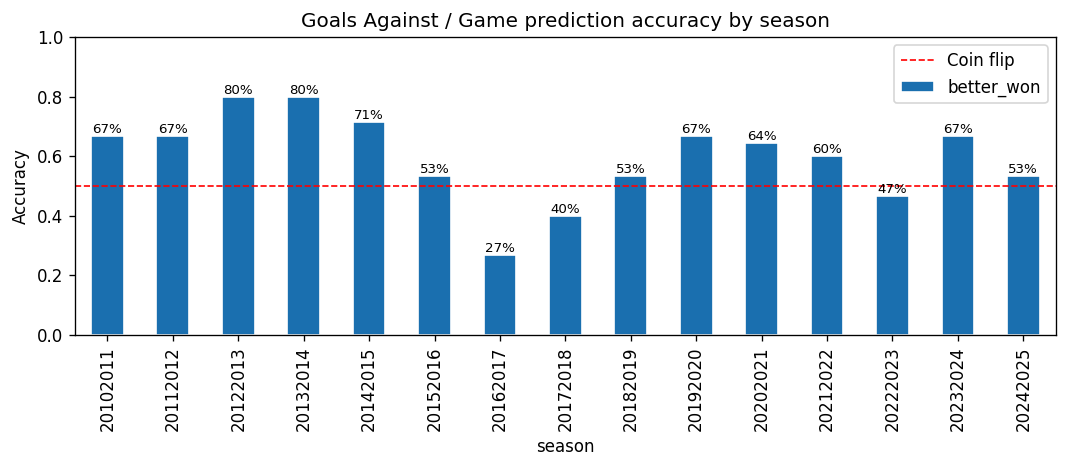

In [6]:
# Per-season consistency: does the best stat hold up year over year?
diff_col = f'{best_stat}_diff'
plot_df = df[[diff_col, 'hi_won', 'season']].dropna().copy()
if best_stat in LOWER_IS_BETTER:
    plot_df[diff_col] = -plot_df[diff_col]

diff = plot_df[diff_col]
plot_df['better_won'] = ((diff > 0) & (plot_df['hi_won'] == 1)) | ((diff < 0) & (plot_df['hi_won'] == 0))
season_acc = plot_df[diff != 0].groupby('season')['better_won'].mean()

ax = season_acc.plot(kind='bar', figsize=(9, 4), color='#1a6faf', edgecolor='white')
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Coin flip')
ax.set_title(f'{best_label} prediction accuracy by season')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.legend()
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0%}', (p.get_x() + p.get_width() / 2, p.get_height() + 0.01),
                ha='center', fontsize=8)
plt.tight_layout()
plt.show()